In [1]:
import matplotlib.pyplot as plt
from qutip import *
import numpy as np

from tomo_plot_hammer import *

In [2]:
spin_dim = 7/2
Ix = jmat(spin_dim,'x')
Iy = jmat(spin_dim,'y')
Iz = jmat(spin_dim,'z')
Ip = jmat(spin_dim, '+')
Im = jmat(spin_dim, '-')

In [3]:
def Hz_order(kappa, order):
    H = kappa * (Iz) **(order) / (order * (7/2) ** (order -1 ))
    return H

# Calculate SNAP angle from H Unitary

In [59]:
def kappa_to_opxPhsae_subspace(kappa, J, initial_state, order):
    if 2*J + initial_state > 2*J:
        raise Exception("Invalid Subspace size/Starting state")
    A = -np.tri(int(2*J), int(2*J), 0)
    A_inv = np.linalg.inv(A)
    Iz = operators.jmat(J,'z')
    # kappa = np.pi / 4  # decide SNAP angle

    SNAP = (-1j * (Iz) ** order * kappa/ (order*J**(order-1))).expm()  # find SNAP matrix
    SNAP_angle = np.angle(SNAP.diag()) * 180 / np.pi  # get phi from SNAP matrix
    SNAP_angle = SNAP_angle - SNAP_angle[0]  # reference element 0
    opx_phase = A_inv @ SNAP_angle[1:]  # get chi from inverse matrix
    opx_phase_SNAP = ((opx_phase)/360 )%1
    opx_phase_SNAP = np.round(opx_phase_SNAP, 6).tolist()
    # print(opx_phase_SNAP)
    mask_list = [0]*int(initial_state) + [1]*int(J*2) + [0]*int(7-initial_state-J*2)
    result = []
    a_index = 0
    
    for m in mask_list:
        if m == 1:
            result.append(opx_phase_SNAP[a_index])
            a_index += 1
        else:
            result.append(0)
    return result

In [ ]:
def kappa_to_opxPhsae_subspace(kappa, J, initial_state, order):
    if 2*J + initial_state > 2*J:
        raise Exception("Invalid Subspace size/Starting state")
    A = -np.tri(int(2*J), int(2*J), 0)
    A_inv = np.linalg.inv(A)
    Iz = qt.operators.jmat(J,'z')
    # kappa = np.pi / 4  # decide SNAP angle

    SNAP = (-1j * Iz ** order * kappa/ (order*J**(order-1))).expm()  # find SNAP matrix
    SNAP_angle = np.angle(SNAP.diag()) * 180 / np.pi  # get phi from SNAP matrix
    SNAP_angle = SNAP_angle - SNAP_angle[0]  # reference element 0
    opx_phase = A_inv @ SNAP_angle[1:]  # get chi from inverse matrix
    opx_phase_SNAP = ((opx_phase)/360 )%1
    opx_phase_SNAP = (-1*np.round(opx_phase_SNAP, 6)).tolist()
    # print(opx_phase_SNAP)
    mask_list = [0]*int(initial_state) + [1]*int(J*2) + [0]*int(7-initial_state-J*2)
    result = []
    a_index = 0
    
    for m in mask_list:
        if m == 1:
            result.append(opx_phase_SNAP[a_index])
            a_index += 1
        else:
            result.append(0)
    return result

In [ ]:
# Step 0
order = 2
J = 7/2
initial_state = 0
# Step 1, gamma
gamma = 400 #Hz
# Step 2, simulation time step tau
T_total = 1200e-6
trotter_num = 10
tau = T_total/trotter_num
# Step 3 U_SNAP
kappa = 2*np.pi*gamma * tau

In [63]:
# Step 0
order = 3
J = 7/2
initial_state = 0
gamma = 400
kappa = 2*np.pi*gamma
T_total = 1.2e-3
trotter_num = 20
tau = T_total/trotter_num

phase_list = kappa_to_opxPhsae_subspace(kappa * tau, J, initial_state, order) ##### ! Enter higher order here ! ####
A = -np.tri(int(2*J), int(2*J), 0)
A_inv = np.linalg.inv(A)
snap_phase = A @ (np.array(phase_list) * 2* np.pi)
snap_phase_append = np.insert(snap_phase, 0, 0)
# snap_phase = (-1j * tau * Qobj(Hzz)).expm().diag()
Uzz_recon = Qobj(np.diag(np.exp(1j*snap_phase_append)))



# Hilbert space dimension
d = 8
Hzz = Hz_order(kappa, order)
 
# su(2) drivign strength
rabi_strength = 2*np.pi*1/(2*(1888409/1e9))
 
Hy = rabi_strength * -Iy#-Iy
 
H_drive = Hy + Hzz


In [64]:
phase_list

[0.982204, 0.992, 0.997878, 0.999837, 0.997878, 0.992, 0.982204]

# Trotterization

In [55]:
psi0 = basis(d, 0)
rho0 = psi0 * psi0.dag()
projectors = [basis(d, j) * basis(d, j).dag() for j in range(d)]

# Storage as indexable lists
rho_trajectories = []   # [sweep_idx][n] -> Qobj density matrix
exp_comps_all   = []    # [sweep_idx] -> array shape (d, trotter_num+1)
step_idx_all    = []    # [sweep_idx] -> np.arange(trotter_num+1)

# when we sweep dt from 100 µs to 1500 µs
trotter_num_list = [trotter_num]#np.flip(np.arange(1,13))


for trotter_num in trotter_num_list:
    # trotter_num = int(np.floor(t_max / dt))  # integer # of steps for this dt
    dt = T_total / trotter_num
    # Allocate
    rho_t = [None] * (trotter_num + 1)
    rho_t[0] = rho0

    exp_comps = np.zeros((d, trotter_num + 1), dtype=float)
    exp_comps[:, 0] = np.real(np.diag(rho0.full())).ravel()

    # Precompute single-step unitary for this dt (time-independent Trotter-1)
    Uy  = (-1j * dt * Qobj(Hy)).expm()
    Uzz = (-1j * dt * Qobj(Hzz)).expm()
    U   = Uzz * Uy 

    # Loop n = 0..trotter_num (inclusive); n=0 is already initialized
    for n in range(0, trotter_num + 1):
        if n == 0:
            continue
        rho_t[n] = U * rho_t[n - 1] * U.dag()
        for j, Pj in enumerate(projectors):
            exp_comps[j, n] = expect(Pj, rho_t[n]).real

    # Store for this sweep
    rho_trajectories.append(rho_t)
    exp_comps_all.append(exp_comps)
    step_idx_all.append(np.arange(trotter_num + 1))


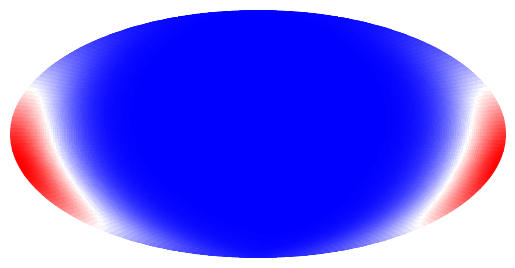

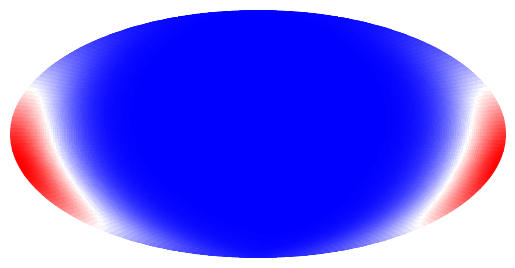

In [56]:
tomo_plot_hammer(rho_trajectories[-1][-1], "h")

In [57]:
psi0 = basis(d, 0)
rho0 = psi0 * psi0.dag()
projectors = [basis(d, j) * basis(d, j).dag() for j in range(d)]

# Storage as indexable lists
rho_trajectories_recon = []   # [sweep_idx][n] -> Qobj density matrix
exp_comps_all   = []    # [sweep_idx] -> array shape (d, trotter_num+1)
step_idx_all    = []    # [sweep_idx] -> np.arange(trotter_num+1)

# when we sweep dt from 100 µs to 1500 µs
trotter_num_list = [trotter_num]#np.flip(np.arange(1,13))


for trotter_num in trotter_num_list:
    # trotter_num = int(np.floor(t_max / dt))  # integer # of steps for this dt
    dt = T_total / trotter_num
    # Allocate
    rho_t = [None] * (trotter_num + 1)
    rho_t[0] = rho0

    exp_comps = np.zeros((d, trotter_num + 1), dtype=float)
    exp_comps[:, 0] = np.real(np.diag(rho0.full())).ravel()

    # Precompute single-step unitary for this dt (time-independent Trotter-1)
    Uy  = (-1j * dt * Qobj(Hy)).expm()
    # Uzz = (-1j * dt * Qobj(Hzz)).expm()
    U = Uzz_recon * Uy 

    # Loop n = 0..trotter_num (inclusive); n=0 is already initialized
    for n in range(0, trotter_num + 1):
        if n == 0:
            continue
        rho_t[n] = U * rho_t[n - 1] * U.dag()
        for j, Pj in enumerate(projectors):
            exp_comps[j, n] = expect(Pj, rho_t[n]).real

    # Store for this sweep
    rho_trajectories_recon.append(rho_t)
    exp_comps_all.append(exp_comps)
    step_idx_all.append(np.arange(trotter_num + 1))


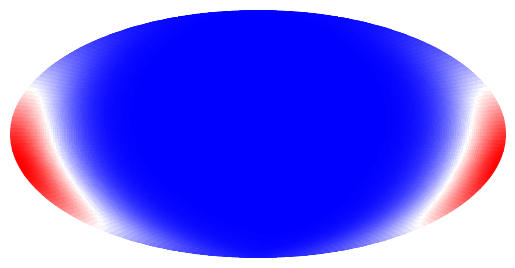

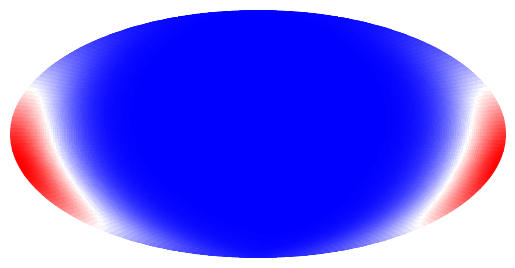

In [58]:
tomo_plot_hammer(rho_trajectories_recon[-1][-1], "h")